# Injection Molding Defect Prediction - Exploratory Data Analysis

This notebook explores the data before I build any models. The goal of the project is to predict whether a plastic injection molding cycle produced a good or defective part from the machine's process parameters.

I work with two datasets:

1. **Injection molding quality** (airtlab / iGuzzini) - 1,451 real production cycles, 13 process parameters, and a quality label. This is the main dataset for the project.
2. **SECOM** (UCI) - a semiconductor manufacturing quality dataset with a strong class imbalance. I bring it in to show the same defect prediction idea on a harder, more imbalanced case later in the project.

In this notebook I focus on understanding the data: shapes, types, missing values, the class balance, how the features are distributed, and how they relate to each other and to the quality label. The findings here decide what cleaning and feature work I do before modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load the injection molding data

The file is semicolon separated, so I tell pandas to use `sep=';'`. Each row is one molding cycle. The last column, `quality`, is the label.

In [2]:
df = pd.read_csv('../data/raw/injection_molding.csv', sep=';')
print('Shape:', df.shape)
df.head()

Shape: (1451, 14)


,Melt temperature,Mold temperature,time_to_fill,ZDx - Plasticizing time,ZUx - Cycle time,SKx - Closing force,SKs - Clamping force peak value,Ms - Torque peak value current cycle,Mm - Torque mean value current cycle,APSs - Specific back pressure peak value,APVs - Specific injection pressure peak value,CPn - Screw position at the end of hold pressure,SVo - Shot volume,quality
0,106.476184,80.617,7.124,3.16,74.83,886.900000,904.000000,116.9,104.300000,145.6,922.3,8.82,18.73,1.0
1,105.505000,81.362,6.968,3.16,74.81,919.409791,935.900000,113.9,104.900000,145.6,930.5,8.59,18.73,1.0
2,105.505000,80.411,6.864,4.08,74.81,908.600000,902.344823,120.5,106.503496,147.0,933.1,8.80,18.98,1.0
3,106.474827,81.162,6.864,3.16,74.82,879.410871,902.033653,127.3,104.900000,145.6,922.3,8.85,18.73,1.0
4,106.466140,81.471,6.864,3.22,74.83,885.644260,902.821269,120.5,106.700000,145.6,917.5,8.80,18.75,1.0


The column names are long machine codes. I rename them to short, readable names so the rest of the notebook is easier to follow. I keep the original meaning in a comment.

In [3]:
# original -> short readable name
rename = {
    'Melt temperature': 'melt_temp',
    'Mold temperature': 'mold_temp',
    'time_to_fill': 'fill_time',
    'ZDx - Plasticizing time': 'plasticizing_time',
    'ZUx - Cycle time': 'cycle_time',
    'SKx - Closing force': 'closing_force',
    'SKs - Clamping force peak value': 'clamping_force_peak',
    'Ms - Torque peak value current cycle': 'torque_peak',
    'Mm - Torque mean value current cycle': 'torque_mean',
    'APSs - Specific back pressure peak value': 'back_pressure_peak',
    'APVs - Specific injection pressure peak value': 'injection_pressure_peak',
    'CPn - Screw position at the end of hold pressure': 'screw_position',
    'SVo - Shot volume': 'shot_volume',
}
df = df.rename(columns=rename)
feature_cols = list(rename.values())
print('Features:', feature_cols)
df.head()

Features: ['melt_temp', 'mold_temp', 'fill_time', 'plasticizing_time', 'cycle_time', 'closing_force', 'clamping_force_peak', 'torque_peak', 'torque_mean', 'back_pressure_peak', 'injection_pressure_peak', 'screw_position', 'shot_volume']


,melt_temp,mold_temp,fill_time,plasticizing_time,cycle_time,closing_force,clamping_force_peak,torque_peak,torque_mean,back_pressure_peak,injection_pressure_peak,screw_position,shot_volume,quality
0,106.476184,80.617,7.124,3.16,74.83,886.900000,904.000000,116.9,104.300000,145.6,922.3,8.82,18.73,1.0
1,105.505000,81.362,6.968,3.16,74.81,919.409791,935.900000,113.9,104.900000,145.6,930.5,8.59,18.73,1.0
2,105.505000,80.411,6.864,4.08,74.81,908.600000,902.344823,120.5,106.503496,147.0,933.1,8.80,18.98,1.0
3,106.474827,81.162,6.864,3.16,74.82,879.410871,902.033653,127.3,104.900000,145.6,922.3,8.85,18.73,1.0
4,106.466140,81.471,6.864,3.22,74.83,885.644260,902.821269,120.5,106.700000,145.6,917.5,8.80,18.75,1.0


## 2. Data types and missing values

Before anything else I check that every column loaded as a number and that there are no gaps. Missing or wrongly typed data would break the models later.

In [4]:
df.info()
print('\nMissing values per column:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1451 entries, 0 to 1450
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   melt_temp                1451 non-null   float64
 1   mold_temp                1451 non-null   float64
 2   fill_time                1451 non-null   float64
 3   plasticizing_time        1451 non-null   float64
 4   cycle_time               1451 non-null   float64
 5   closing_force            1451 non-null   float64
 6   clamping_force_peak      1451 non-null   float64
 7   torque_peak              1451 non-null   float64
 8   torque_mean              1451 non-null   float64
 9   back_pressure_peak       1451 non-null   float64
 10  injection_pressure_peak  1451 non-null   float64
 11  screw_position           1451 non-null   float64
 12  shot_volume              1451 non-null   float64
 13  quality                  1451 non-null   float64
dtypes: float64(14)
memory usage: 158.8 

All 13 features and the label are `float64`, there are no missing values, and no duplicate rows. That is unusually clean, which makes sense because it is curated lab data rather than a raw factory dump. So I do not need imputation here. On the SECOM dataset later I expect the opposite.

## 3. Summary statistics

`describe()` gives me the range and spread of each parameter. I am looking for features on very different scales, since that tells me scaling will matter for distance and gradient based models.

In [5]:
df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
melt_temp,1451.0,106.892040,5.615773,81.747,105.9145,106.0890,106.263000,155.032
mold_temp,1451.0,81.326023,0.428813,78.409,81.1235,81.3270,81.441000,82.159
fill_time,1451.0,7.459043,1.688106,6.084,6.2920,6.9680,7.124000,11.232
plasticizing_time,1451.0,3.234173,0.343230,2.780,3.0000,3.1926,3.290000,6.610
cycle_time,1451.0,75.218794,0.432761,74.780,74.8200,74.8300,75.650000,75.790
closing_force,1451.0,901.974834,11.098192,876.700,893.6000,902.4000,909.400000,930.600
clamping_force_peak,1451.0,919.351778,10.780023,894.800,914.4000,918.8000,926.300000,946.500
torque_peak,1451.0,116.716747,5.029085,94.200,114.2000,116.9000,120.200000,130.300
torque_mean,1451.0,104.163904,4.802195,76.500,103.5500,105.2000,106.531415,114.900
back_pressure_peak,1451.0,146.230048,0.804894,144.800,145.6000,146.1000,146.700000,150.500


## 4. The quality label

The `quality` column is the target. From the dataset paper, the lenses were graded by a photometric uniformity measure into four classes:

- 1 = Waste: fails the standard, must be scrapped
- 2 = Acceptable: passes the standard but below the company's target
- 3 = Target: the optimal quality the company wants
- 4 = Inefficient: over quality, passes easily but wastes machine resources, so it is also undesirable

I check how the four classes are spread out, because that decides which evaluation metrics make sense. Accuracy is misleading when one class dominates.

1 (Waste): 370  (25.5%)
2 (Acceptable): 406  (28.0%)
3 (Target): 310  (21.4%)
4 (Inefficient): 365  (25.2%)


C:\Users\Admin\AppData\Local\Temp\ipykernel_124952\2219549837.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{l}\n{quality_names[l]}' for l in counts.index])


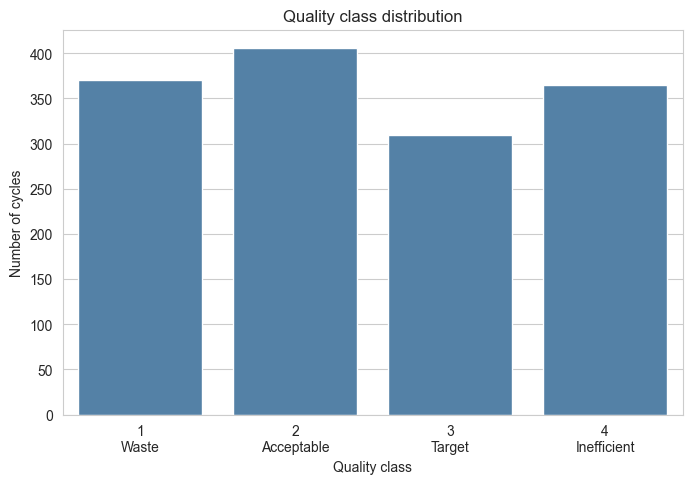

In [6]:
quality_names = {1: 'Waste', 2: 'Acceptable', 3: 'Target', 4: 'Inefficient'}
df['quality'] = df['quality'].astype(int)

counts = df['quality'].value_counts().sort_index()
for label, n in counts.items():
    print(f'{label} ({quality_names[label]}): {n}  ({n/len(df)*100:.1f}%)')

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='quality', data=df, color='steelblue')
ax.set_xticklabels([f'{l}\n{quality_names[l]}' for l in counts.index])
plt.title('Quality class distribution')
plt.xlabel('Quality class')
plt.ylabel('Number of cycles')
plt.show()

The four classes are fairly balanced, each between about 21 and 28 percent. That is good news, since the modeling will not be fighting a heavy imbalance the way a real scrap rate would be (real defect rates are often a few percent). To still show the imbalance handling that the project promises, I bring in the SECOM dataset later, which is heavily skewed.

For the project I will also create a binary view of the problem, good versus scrap, because on a shop floor the first question is simply "should this part be thrown away". The Waste class is the scrap, the other three are parts that pass the standard.

In [7]:
# binary view: 1 = scrap (Waste), 0 = part passes the standard
df['is_scrap'] = (df['quality'] == 1).astype(int)
print(df['is_scrap'].value_counts())
print('\nScrap rate:', round(df['is_scrap'].mean() * 100, 1), '%')

is_scrap
0    1081
1     370
Name: count, dtype: int64

Scrap rate: 25.5 %


## 5. Feature distributions

I plot a histogram for each of the 13 process parameters to see their shape: whether they are roughly normal, skewed, or have outliers. This tells me if any feature needs a transform before modeling.

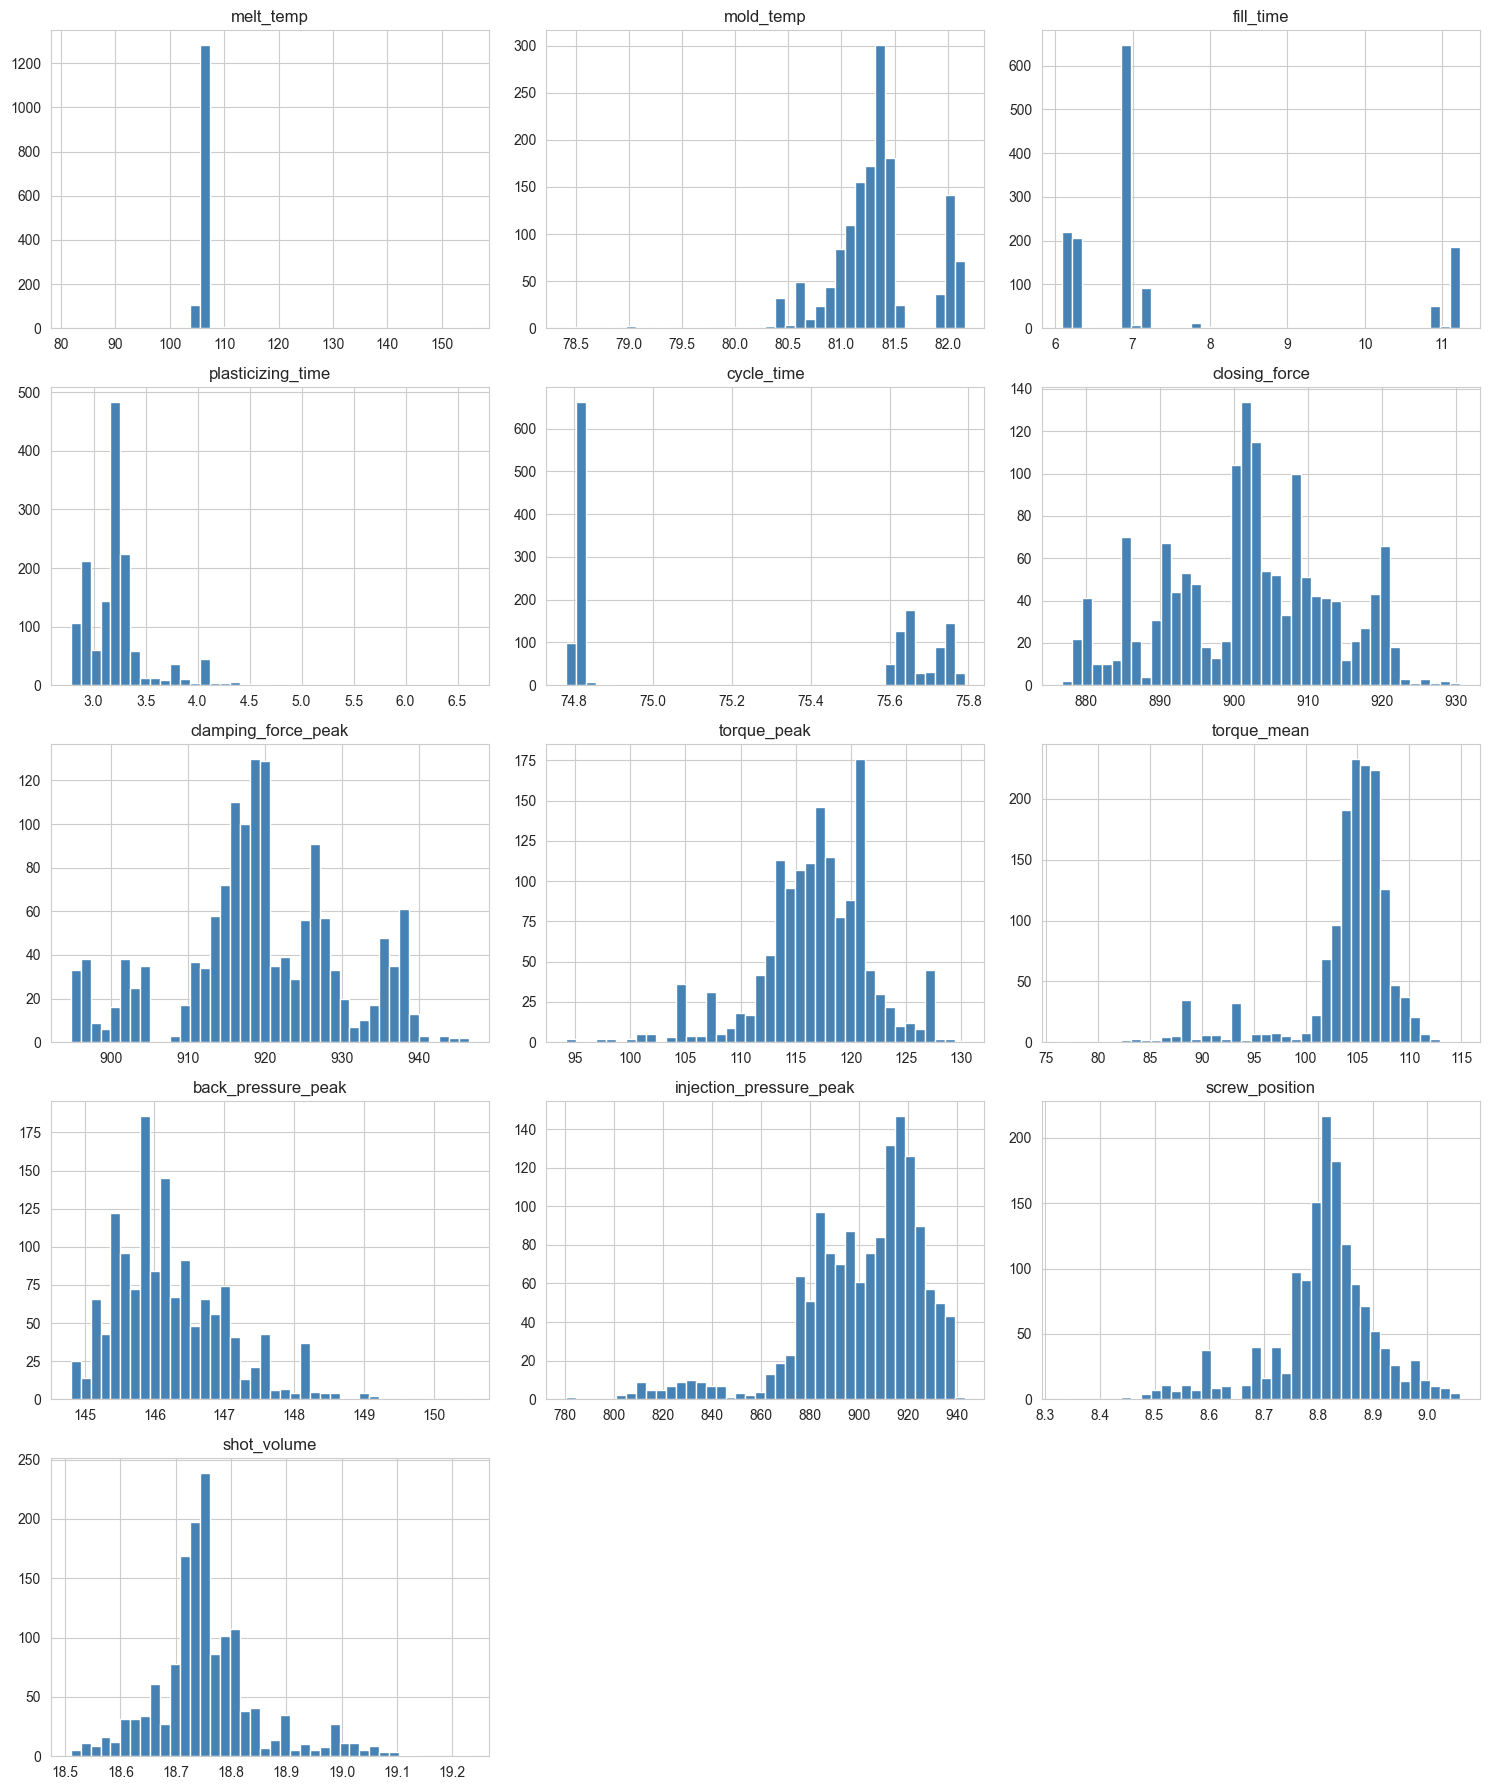

In [8]:
fig, axes = plt.subplots(5, 3, figsize=(15, 18))
axes = axes.ravel()
for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
# hide the unused subplots
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

To back up the eye test, I compute the skew of each feature. A rough rule is that an absolute skew above about 1 is worth looking at for a transform.

In [9]:
skew = df[feature_cols].skew().sort_values(key=abs, ascending=False)
print(skew)

melt_temp                  6.383858
plasticizing_time          2.817124
torque_mean               -2.243204
fill_time                  1.566695
injection_pressure_peak   -1.300690
back_pressure_peak         0.970940
shot_volume                0.910103
screw_position            -0.859329
torque_peak               -0.711094
mold_temp                 -0.591857
clamping_force_peak       -0.198338
cycle_time                 0.160893
closing_force             -0.148245
dtype: float64


A few features are clearly skewed. Melt temperature has a skew of about 6.4, driven by a small number of cycles with a much lower melt temperature than the rest (the minimum is around 82 against a typical 106). Plasticizing time, torque mean, and filling time also have an absolute skew above 1. The rest are close to symmetric.

I will not transform these now. The plan starts with tree based models (Random Forest, Gradient Boosting), which split on thresholds and do not care about skew, so a transform would not help them. For the Logistic Regression baseline I rely on StandardScaler, and I keep the option of a log transform on the worst offenders in the modeling notebook if the linear model underperforms. The point of checking here is to know which features to watch, not to transform blindly.

## 6. How features relate to each other

A correlation heatmap shows which parameters move together. Strongly correlated features carry overlapping information, which is worth knowing before modeling (linear models in particular can be unstable when features are nearly duplicates).

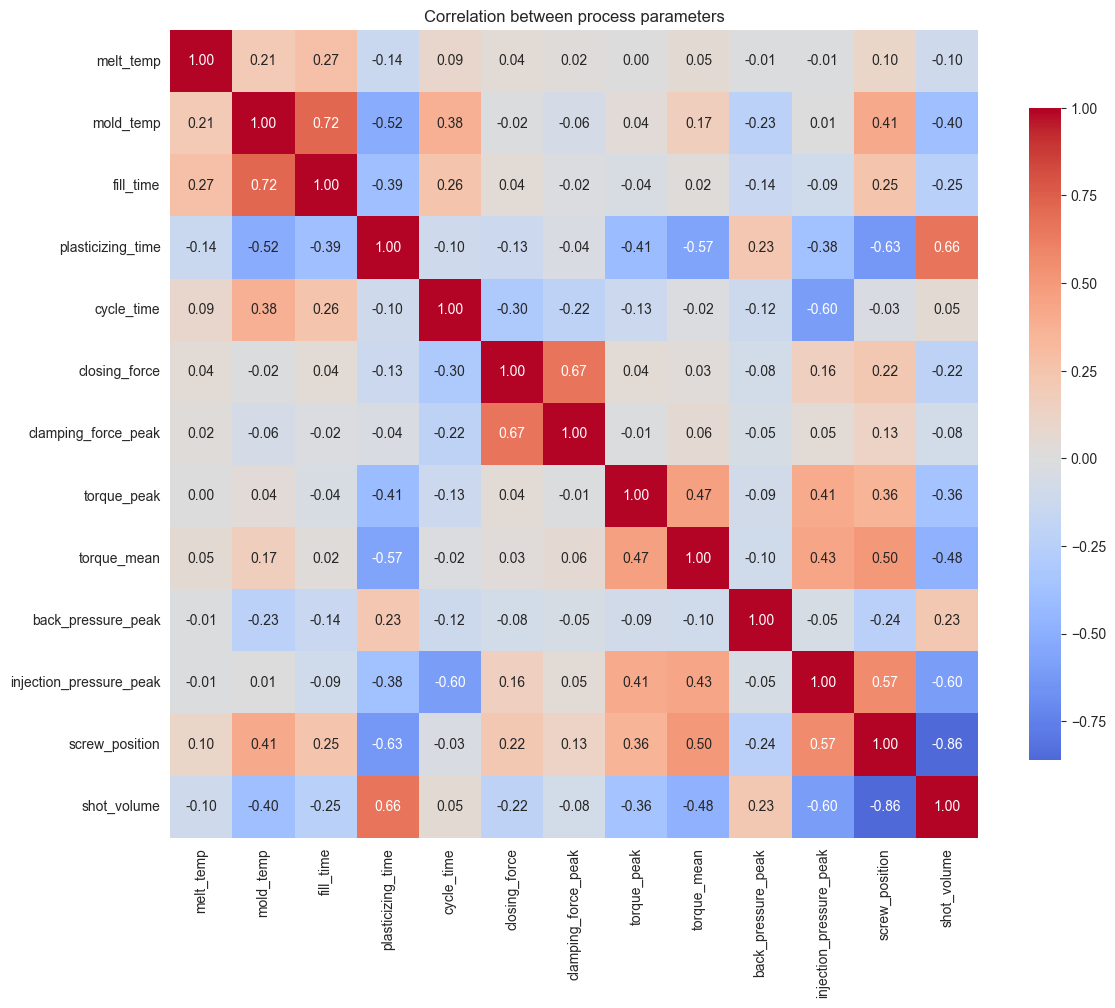

In [10]:
corr = df[feature_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation between process parameters')
plt.tight_layout()
plt.show()

In [11]:
# list the strongest feature pairs so I do not have to read the whole grid by eye
pairs = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print('Strongest correlated parameter pairs:')
print(pairs.sort_values(ascending=False).head(8))

Strongest correlated parameter pairs:
screw_position           shot_volume                0.860902
mold_temp                fill_time                  0.717758
closing_force            clamping_force_peak        0.665070
plasticizing_time        shot_volume                0.659036
                         screw_position             0.633129
injection_pressure_peak  shot_volume                0.603148
cycle_time               injection_pressure_peak    0.599381
injection_pressure_peak  screw_position             0.570872
dtype: float64


The strongest pair is screw position and shot volume at about 0.86, which makes physical sense since both track how much material is pushed into the mold. Other moderate pairs are mold temperature with filling time (0.72) and closing force with clamping force peak (0.67). Nothing is close to a perfect 1.0, so there are no redundant duplicate columns to drop. I keep all 13 features, but I note that the tree models will handle the correlation fine, and if the Logistic Regression looks unstable I can revisit dropping one of a correlated pair.

## 7. Do the parameters separate the quality classes?

This is the key question for the project: do the process parameters actually differ between good and scrap parts? If they do, a model has signal to learn from. I use box plots of each parameter split by quality class. Where the boxes for different classes sit at clearly different levels, that parameter is useful for prediction.

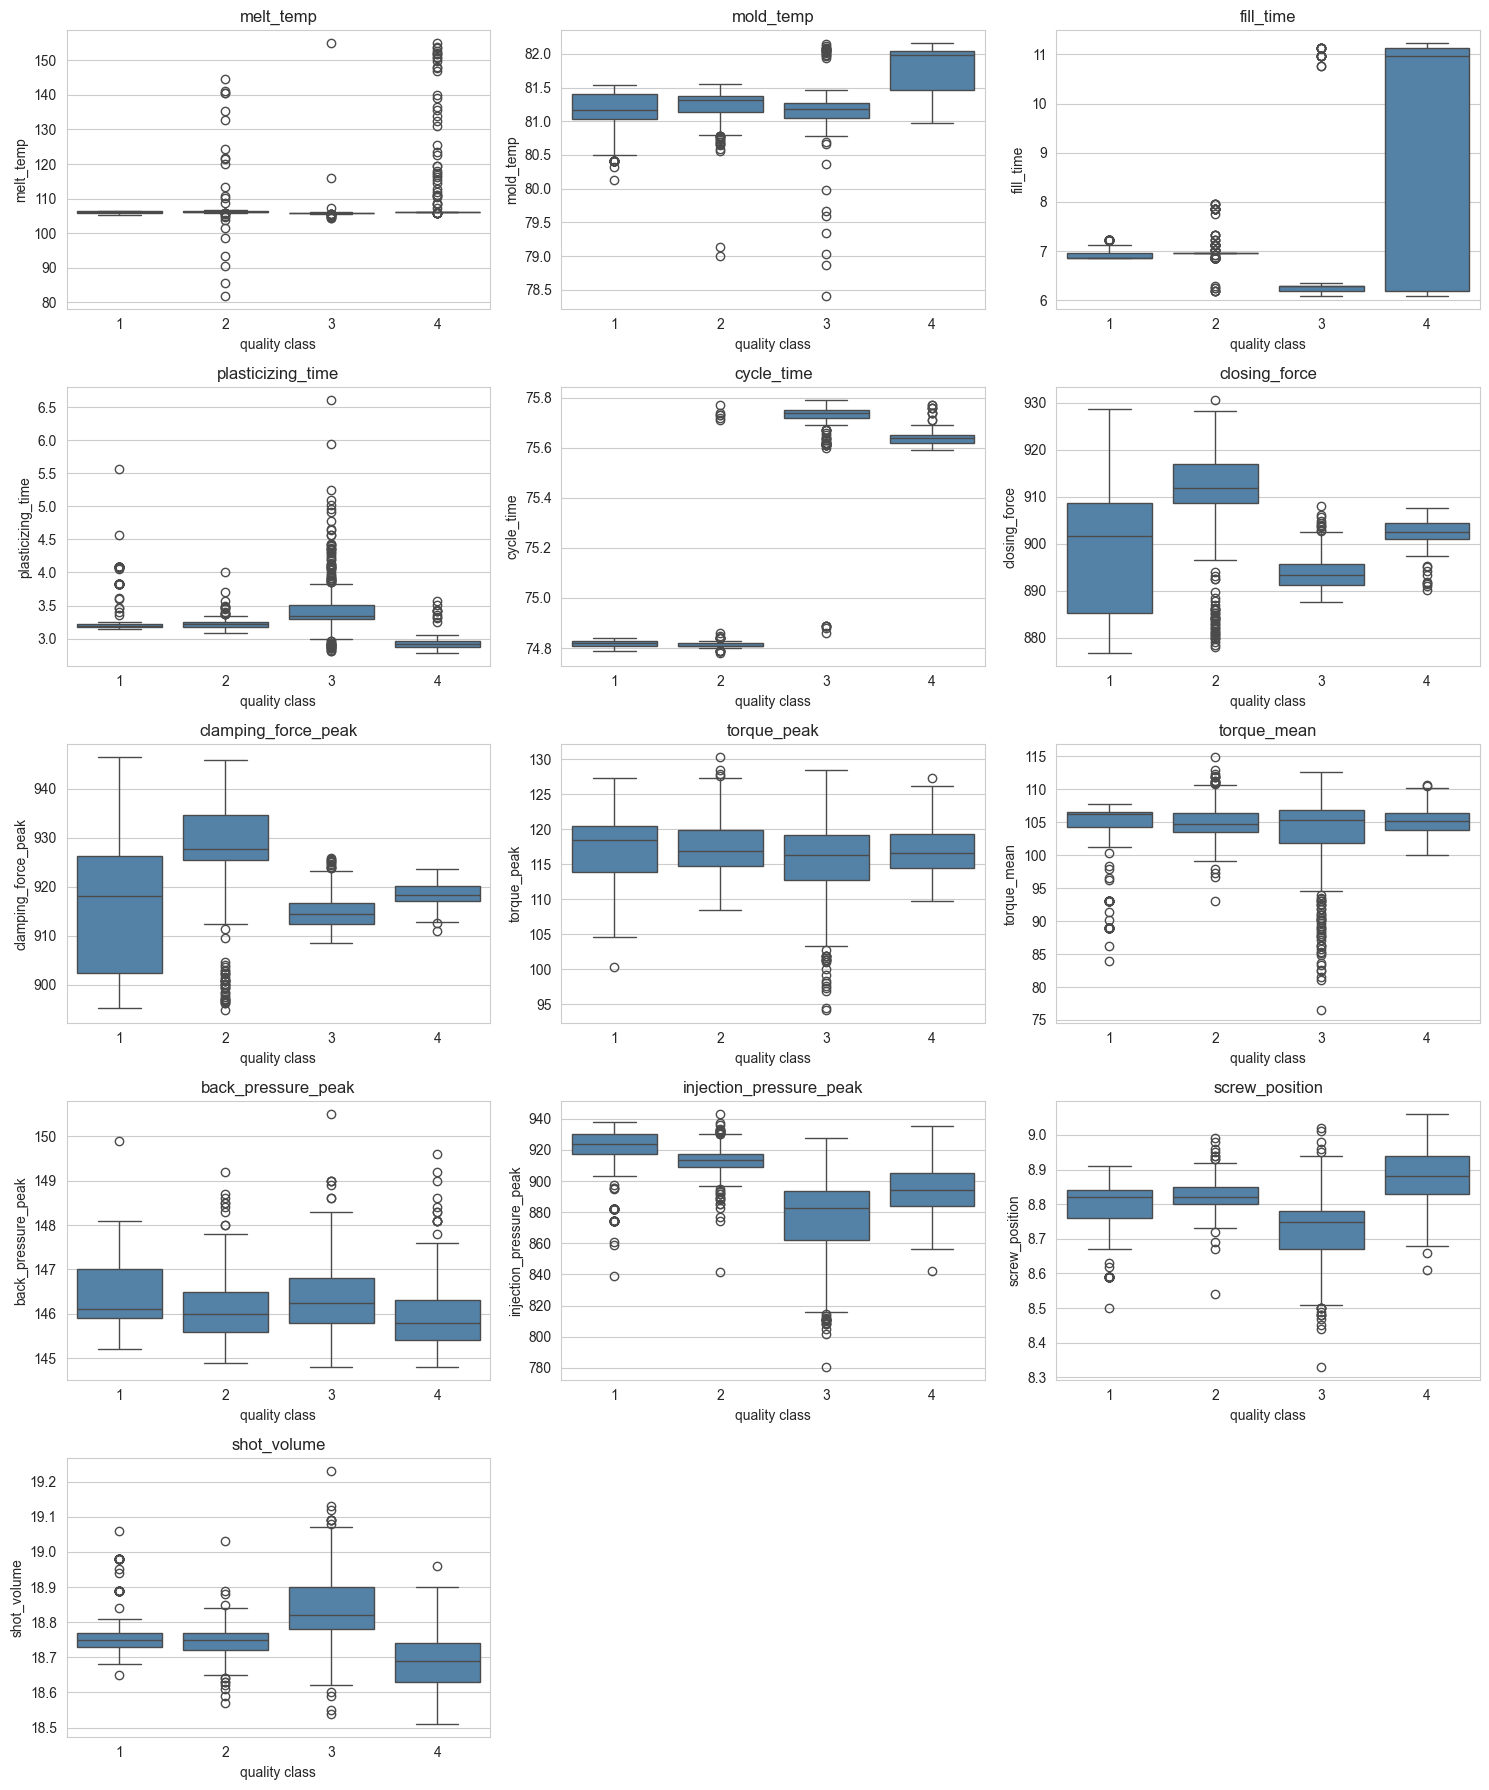

In [12]:
fig, axes = plt.subplots(5, 3, figsize=(15, 18))
axes = axes.ravel()
for i, col in enumerate(feature_cols):
    sns.boxplot(x='quality', y=col, data=df, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('quality class')
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [13]:
# rank features by how strongly they separate the four quality classes (ANOVA F-test)
from sklearn.feature_selection import f_classif

f_vals, p_vals = f_classif(df[feature_cols], df['quality'])
ranking = pd.DataFrame({'feature': feature_cols, 'F_value': f_vals, 'p_value': p_vals})
ranking = ranking.sort_values('F_value', ascending=False).reset_index(drop=True)
print(ranking)

                    feature       F_value        p_value
0                cycle_time  12734.026215   0.000000e+00
1   injection_pressure_peak    376.143807  1.421053e-180
2                 mold_temp    368.878490  6.618050e-178
3                 fill_time    318.606305  8.511142e-159
4               shot_volume    260.649142  3.193381e-135
5            screw_position    258.172857  3.563642e-134
6         plasticizing_time    253.397282  3.821135e-132
7             closing_force    184.425681  2.913170e-101
8       clamping_force_peak    129.188645   3.789148e-74
9        back_pressure_peak     40.680447   3.082125e-25
10              torque_mean     26.034842   2.109852e-16
11                melt_temp     19.530949   2.052412e-12
12              torque_peak     16.154524   2.483532e-10


The box plots and the F-test agree that the parameters do separate the classes. Every feature has a tiny p value, but the F values show a big spread in how much each one matters. Cycle time stands out massively, with an F value around 12,700 against a few hundred for the next best. That is because the four classes in this dataset were produced by deliberately running the machine at different settings, so the machine-level parameters like cycle time, injection pressure, mold temperature, and filling time line up almost directly with the quality class.

This is good for prediction accuracy but I keep it in mind honestly: a model that leans almost entirely on cycle time is really learning which production setting was used, not discovering a subtle physical cause of defects. I will report this in the modeling notebook and look at how the model does when the dominant feature is less obvious. The torque and melt temperature features carry the least separating power.

## 8. SECOM dataset (the imbalanced case)

SECOM is a real semiconductor manufacturing dataset from the UCI repository. Each row is a production run with 590 sensor measurements and a pass or fail label. I load it mainly to confirm the two things I need from it: a heavy class imbalance and a lot of missing values, which is what makes it a harder, more realistic defect prediction problem than the clean molding data.

In [14]:
secom = pd.read_csv('../data/raw/secom.data', sep=' ', header=None)
secom_labels = pd.read_csv('../data/raw/secom_labels.data', sep=' ', header=None)
secom_y = secom_labels[0]  # -1 = pass, 1 = fail

print('SECOM shape:', secom.shape)
print('\nLabel counts (-1 = pass, 1 = fail):')
print(secom_y.value_counts())
fail_rate = (secom_y == 1).mean() * 100
print(f'\nFail rate: {fail_rate:.1f}%  (about {round((secom_y==-1).sum()/(secom_y==1).sum())} to 1 imbalance)')

missing_pct = secom.isnull().sum().sum() / (secom.shape[0] * secom.shape[1]) * 100
print(f'Missing cells: {missing_pct:.1f}% of the table')

SECOM shape: (1567, 590)

Label counts (-1 = pass, 1 = fail):
0
-1    1463
 1     104
Name: count, dtype: int64

Fail rate: 6.6%  (about 14 to 1 imbalance)
Missing cells: 4.5% of the table


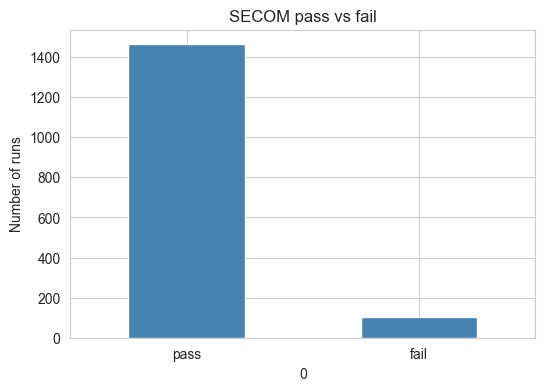

In [15]:
plt.figure(figsize=(6, 4))
secom_y.map({-1: 'pass', 1: 'fail'}).value_counts().plot(kind='bar', color='steelblue')
plt.title('SECOM pass vs fail')
plt.ylabel('Number of runs')
plt.xticks(rotation=0)
plt.show()

## 9. Save the cleaned molding data

I save the renamed molding data, with the binary scrap column added, so the modeling notebook can load it directly without repeating the cleaning.

In [16]:
import os
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/molding_clean.csv', index=False)
print('Saved', df.shape, 'to data/processed/molding_clean.csv')

Saved (1451, 15) to data/processed/molding_clean.csv


## 10. Summary of findings

What I learned from this EDA, and what it means for the modeling step:

1. The molding dataset is small but clean: 1,451 cycles, 13 numeric process parameters, no missing values, no duplicates. So no imputation is needed on this dataset.

2. The four quality classes (Waste, Acceptable, Target, Inefficient) are fairly balanced, each roughly a quarter of the data. I will report macro F1 and a confusion matrix alongside accuracy, but the balance means accuracy is not as misleading here as it would be in a real factory.

3. The features sit on very different scales, so I will apply StandardScaler before the Logistic Regression baseline. Tree models do not need it.

4. Some features are skewed, melt temperature heavily so because of a few low outlier cycles. I checked first rather than transforming blindly, and decided not to transform now since the main models are tree based. I keep a log transform as a fallback for the linear model.

5. The parameters clearly separate the classes, with cycle time by far the strongest signal. I am honest that this partly reflects the classes being produced at deliberately different machine settings, so the model is partly learning the setting rather than a hidden defect cause. I will note this when interpreting results.

6. SECOM gives me the imbalanced, missing-heavy case (about 14 to 1, around 4.5 percent missing) that the clean molding data does not, so I can still demonstrate SMOTE, class weighting, and imputation as the proposal promised.

Next step is the modeling notebook: time aware or stratified train and test split, scaling, the Logistic Regression baseline, then Random Forest and Gradient Boosting with cross validation and tuning, evaluated on the metrics above, followed by the anomaly detection and SHAP explainability sections.